# Final Analysis and Comparison of 6 CNN Models for the Waste Classification Dataset

## 1) Overall Model Comparison

### - Validation Loss and Accuracy between Models

In [1]:
import pandas as pd

loss = [2.8811, 1.2270, 1.0630, 1.3569, 0.3771, 0.2280]

accuracy = [55.33, 57.12, 62.10, 50.62, 90.73, 91.70]

model_comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Augmented",
        "Upgraded",
        "Scheduler",
        "ResNet",
        "EfficientNet"
    ],
    "Validation Loss": loss,
    "Validation Accuracy": accuracy
})

model_comparison.style \
    .hide(axis="index") \
    .format({"Validation Loss" : "{:,.4f}",
             "Validation Accuracy" : "{:,.2f}%"}) \
    .set_table_styles([
        {
            "selector": "th, td",
            "props": [
                ("font-size", "16px"),
                ("padding", "10px")
            ]
        }
    ]) 

Model,Validation Loss,Validation Accuracy
Baseline,2.8811,55.33%
Augmented,1.2270,57.12%
Upgraded,1.0630,62.10%
Scheduler,1.3569,50.62%
ResNet,0.3771,90.73%
EfficientNet,0.2280,91.70%


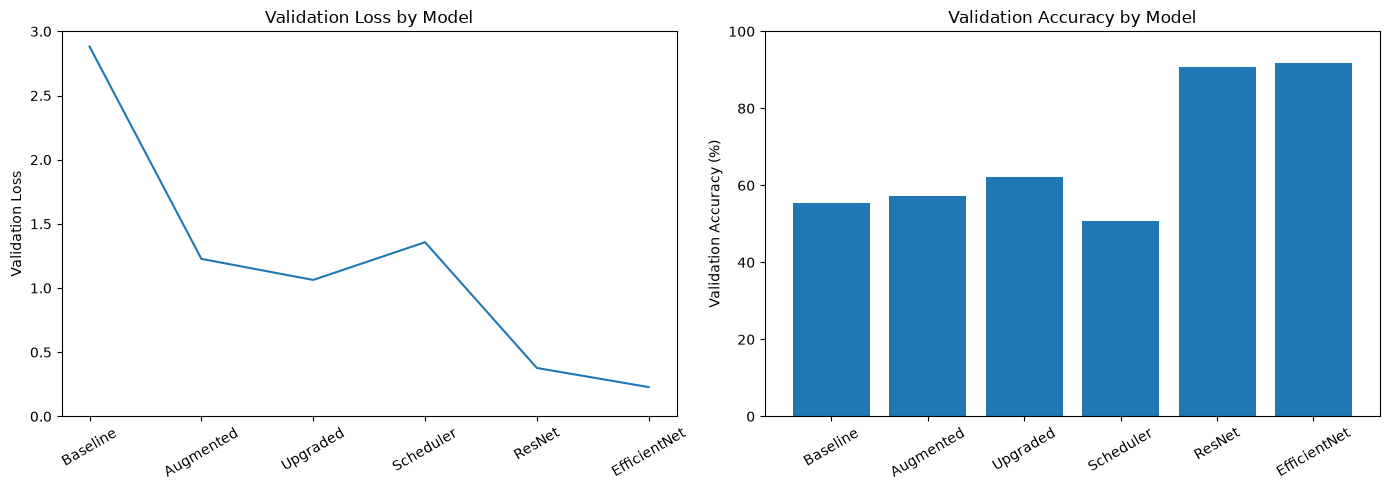

In [2]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Validation Loss
axes[0].plot(model_comparison["Model"], loss)
axes[0].set_title("Validation Loss by Model")
axes[0].set_ylabel("Validation Loss")
axes[0].set_ylim(0, 3)
axes[0].tick_params(axis="x", rotation=30)

# Validation Accuracy
axes[1].bar(model_comparison["Model"], accuracy)
axes[1].set_title("Validation Accuracy by Model")
axes[1].set_ylabel("Validation Accuracy (%)")
axes[1].set_ylim(0, 100)
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

### - Test Metrics for EfficientNet Model

In [3]:
model_testdata = pd.DataFrame({
    "Model": ["EfficientNet"],
    "Test Loss": [0.2682],
    "Test Accuracy": [92.53],
    "Test Precision": [0.9265],
    "Test Recall": [0.9253],
    "Test F1 Score": [0.9251]
})

model_testdata.style \
    .hide(axis="index") \
    .format({"Test Loss" : "{:,.4f}",
             "Test Precision" : "{:,.4f}",
             "Test Recall" : "{:,.4f}",
             "Test F1 Score" : "{:,.4f}",
             "Test Accuracy" : "{:,.2f}%"}) \
    .set_table_styles([
        {
            "selector": "th, td",
            "props": [
                ("font-size", "16px"),
                ("padding", "10px")
            ]
        }
    ])

Model,Test Loss,Test Accuracy,Test Precision,Test Recall,Test F1 Score
EfficientNet,0.2682,92.53%,0.9265,0.9253,0.9251


## 2) What Each Experiment Taught Us

Disclaimer: This will not be a full interpretation of each model, but rather a summary of the most noticeable improvements we observed from one model to another.

. **Baseline to Augmented**: We observed how data augmentation managed to substantially improve validation loss and slightly improve accuracy. This can be attributed in part to better generalization of the Augmented Model.

. **Augmented to Upgraded**: We understood that increasing the number of channels/model capacity can improve performance since the model is able to learn richer features.

. **Upgraded to Scheduler**: We saw that our particular scheduler configuration wasn't beneficial because the learning-rate decay actually hurt the validation performance.

. **Upgraded to ResNet**: A huge jump in both validation metrics showed that Transfer Learning was dramatically more effective than increasing capacity in the custom CNN.

. **ResNet to EfficientNet**: A smaller but still meaningful improvement, likely due to its more complex operations. We concluded that EfficientNet was the strongest model in this experiment based on validation performance.

## 3) Custom CNNs vs Transfer Learning

Among all experiments made throughout the project, the most significant observation was probably the difference between the custom CNNs and the transfer-learning models. The results obtained from our best custom model (Upgraded: 62.10%) are significantly lower compared to ResNet (90.73%) and EfficientNet (91.70%). This clearly shows the real impact that Transfer Learning can have.

Looking exclusively at our case, pre-trained models are valuable in image classification because they save massive amounts of time, data and computing power by starting with an already-educated neural network. Training a model like ResNet or EfficientNet from scratch would typically require an incredible large dataset and substantially more computing resources. The early layers in these networks already know how to detect basic visual patterns like edges, curves and textures. Transfer Learning, with fine-tuning to our own model, is capable of achieving great results with just a relatively small set of custom images.

## 4) What Didn't Work

Looking back at all models, I believe that the Scheduler Model was the one thing that clearly didn't work as planned. In principle, the idea of controlling the step size in order to converge to a better solution sounded reasonable and deserving of experimentation. However, as seen in the validation results, the result was the opposite, since it increased the validation loss and achieved the worst accuracy among the models. Nonetheless, this is quite interesting because it shows that not every theoretically useful technique is guaranteed to improve every model or dataset.

An important last thing is that I would expect the Scheduler Model to potentially perform better with a different step size or even another Learning Rate Scheduler (such as Exponential Decay or Cosine Annealing), but the point of these models was never to keep changing these single hyperparameters until the performance got better. The point here was to experiment with different techniques in order to understand their functionality in practice.

## 5) Limitations and Future Improvements

Here is a list of known limitations in this project that could be useful to consider in future iterations of this project or similar experiments:

- Class balancing
- Early stopping
- Hyperparameter tuning
- Testing different learning-rate schedules
- More extensive reproducibility and seeding
- In-depth investigation of recurrent misclassified classes, such as Plastic being misclassified as Glass or Metal
- Additional Transfer Learning baselines
- Different fine-tuning strategies for Transfer Learning
- Model deployment

## 6) Final Conclusion

Overall, the experiments demonstrated that applying different improvements through either model capacity or specific techniques can improve the generalization of the model, resulting in better-performing models. Ultimately, the best model among the ones trained was EfficientNet, reaching a test accuracy of 92.53% and performing better than any custom CNN we built, thanks to the Transfer Learning approach.